# ***Imports & Notebook Setup***

In [885]:
import pandas as pd

In [886]:
pd.set_option('display.max_columns', None)  # Show all columns
"""
pd.set_option('display.max_rows', None)     # Show all rows (optional, careful if very large!)
pd.set_option('display.max_colwidth', None) # Optional: expand the column width
pd.set_option('display.width', 200) # Optional: display width to prevent wrapping
"""

"\npd.set_option('display.max_rows', None)     # Show all rows (optional, careful if very large!)\npd.set_option('display.max_colwidth', None) # Optional: expand the column width\npd.set_option('display.width', 200) # Optional: display width to prevent wrapping\n"

# ***Data Import***

In [887]:
data = pd.read_csv('./Data/train.csv')
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# ***Data Preprocessing***

In [888]:
data.shape

(891, 12)

***Data Dictionary***

| Variable        | Description                                    | Values / Notes                                  |
|-----------------|------------------------------------------------|-------------------------------------------------|
| **PassengerId** | Numbering index                                |                                                 |
| **Survived**    | Survival status                                | 0 = No, 1 = Yes                                 |
| **Pclass**      | Ticket class (proxy for socio-economic status) | 1 = 1st, 2 = 2nd, 3 = 3rd                       |
| **Name**        | Name of the passenger                          |                                                 |
| **Sex**         | Sex of the passenger                           | Male, Female                                    |
| **Age**         | Age in years                                   |                                                 |
| **SibSp**       | Number of siblings/spouses aboard              |                                                 |
| **Parch**       | Number of parents/children aboard              |                                                 |
| **Ticket**      | Ticket number                                  |                                                 |
| **Fare**        | Passenger fare                                 |                                                 |
| **Cabin**       | Cabin number                                   |                                                 |
| **Embarked**    | Port of embarkation                            | C = Cherbourg, Q = Queenstown, S = Southampton  |

***Drop PassengerId as it's purely a Numbering Index***

In [889]:
data.drop(columns='PassengerId', inplace=True) 
data.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## ***Handle Missing Values***

In [890]:
data.isnull().sum()

Survived      0
Pclass        0
Name          0
Sex           0
Age         177
SibSp         0
Parch         0
Ticket        0
Fare          0
Cabin       687
Embarked      2
dtype: int64

### ***Cabin***

The Cabin feature contains a large number of missing values and will therefore be dropped from the dataset.

In [891]:
data.drop(columns='Cabin', inplace=True)

### ***Age***

Perform group-wise imputation of missing Age values using passenger titles.

In [892]:
data['Title'] = data['Name'].apply(lambda x: x.split(',')[1].split()[0].strip().replace('.', ''))
data.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Title
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,Mr
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,Mrs
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,Miss
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,Mrs
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,Mr


In [893]:
print('Number of unique Titles:', len(data.Title.value_counts()))
data.Title.value_counts()

Number of unique Titles: 17


Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Mlle          2
Major         2
Col           2
the           1
Capt          1
Ms            1
Sir           1
Lady          1
Mme           1
Don           1
Jonkheer      1
Name: count, dtype: int64

In [894]:
title_alias_map = {
    "Mlle": "Miss",
    "Ms": "Miss",
    "Mme": "Mrs",
    }

titles = ['Mr', 'Mrs', 'Miss', 'Master', 'Dr', 'Rev']

data['Title'] = data['Title'].replace(title_alias_map).apply(
    lambda x: x if x in titles else 'Rare'
    )

In [895]:
print('Number of unique Titles:', len(data.Title.value_counts()))
data.Title.value_counts()

Number of unique Titles: 7


Title
Mr        517
Miss      185
Mrs       126
Master     40
Rare       10
Dr          7
Rev         6
Name: count, dtype: int64

In [896]:
title_age_imputation_map = data.groupby('Title')['Age'].mean()
title_age_imputation_map

Title
Dr        42.000000
Master     4.574167
Miss      21.845638
Mr        32.368090
Mrs       35.788991
Rare      49.100000
Rev       43.166667
Name: Age, dtype: float64

In [897]:
data.Age = data.Age.fillna(data.Title.map(title_age_imputation_map))

In [898]:
data.isnull().sum()

Survived    0
Pclass      0
Name        0
Sex         0
Age         0
SibSp       0
Parch       0
Ticket      0
Fare        0
Embarked    2
Title       0
dtype: int64

### ***Embarked***

Perform imputation of missing Embarked values using the most frequent embarkation port.

In [899]:
data.Embarked.value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [900]:
data.Embarked = data.Embarked.fillna(data.Embarked.mode()[0])

In [901]:
data.isnull().sum()

Survived    0
Pclass      0
Name        0
Sex         0
Age         0
SibSp       0
Parch       0
Ticket      0
Fare        0
Embarked    0
Title       0
dtype: int64

## ***Feature Enginnering***

In [902]:
data.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Title
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,Mr
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,Mrs
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,Miss
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,Mrs
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,Mr


### ***Feature-Enginnering Check List***

1. Create **FamilySize** by combining `SibSp` and `Parch` (+1 to include the passenger).

2. Create **TicketGroupSize** by counting the number of passengers sharing the same `Ticket`.

3. Create binary features:
   - **IsAlone**: 1 if `FamilySize == 1`, otherwise 0  
   - **IsSoloTraveler**: 1 if `TicketGroupSize == 1`, otherwise 0  
   - **IsChild**: 1 if `Age < 16`, otherwise 0  

4. Create **FarePerPerson** by dividing `Fare` by `TicketGroupSize` to approximate individual fare.

5. Apply **one-hot encoding** to the **Embarked** feature.

6. Rework ***Title*** Feature

7. Drop the **Name, Ticket, SibSp, Parch**.

8. Encode **Sex** as a binary variable: `female = 0`, `male = 1`

9. Rearrange feature order for improved readability and organization of the final dataset.

### 1. Create **FamilySize** by combining `SibSp` and `Parch` (+1 to include the passenger).

In [903]:
data['FamilySize'] = data['SibSp'] + data['Parch'] + 1

In [904]:
data.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Title,FamilySize
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,Mr,2
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,Mrs,2
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,Miss,1
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,Mrs,2
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,Mr,1


### 2. Create **TicketGroupSize** by counting the number of passengers sharing the same `Ticket`.

In [905]:
data['TicketGroupSize'] = data.groupby('Ticket')['Ticket'].transform('count')

In [906]:
data.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Title,FamilySize,TicketGroupSize
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,Mr,2,1
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,Mrs,2,1
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,Miss,1,1
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,Mrs,2,2
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,Mr,1,1


### 3. Create binary features:
   - **IsAlone**: 1 if `FamilySize == 1`, otherwise 0  
   - **IsSoloTraveler**: 1 if `TicketGroupSize == 1`, otherwise 0  
   - **IsChild**: 1 if `Age < 16`, otherwise 0

In [907]:
data['IsAlone'] = (data['FamilySize'] == 1).astype(int)
data['IsSoloTraveler'] = (data['TicketGroupSize'] == 1).astype(int)
data['IsChild'] = (data['Age'] < 16).astype(int)

In [908]:
data.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Title,FamilySize,TicketGroupSize,IsAlone,IsSoloTraveler,IsChild
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,Mr,2,1,0,1,0
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,Mrs,2,1,0,1,0
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,Miss,1,1,1,1,0
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,Mrs,2,2,0,0,0
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,Mr,1,1,1,1,0


### 4. Create **FarePerPerson** by dividing `Fare` by `TicketGroupSize` to approximate individual fare.

In [909]:
data['FarePerPerson'] = data['Fare']/data['TicketGroupSize']

In [910]:
data.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Title,FamilySize,TicketGroupSize,IsAlone,IsSoloTraveler,IsChild,FarePerPerson
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,Mr,2,1,0,1,0,7.2500
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,Mrs,2,1,0,1,0,71.2833
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,Miss,1,1,1,1,0,7.9250
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,Mrs,2,2,0,0,0,26.5500
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,Mr,1,1,1,1,0,8.0500


### 5. Apply **one-hot encoding** to the **Embarked** feature.

In [911]:
# ensure fixed category space
data['Embarked'] = pd.Categorical(
    data['Embarked'],
    categories=['C', 'Q', 'S']
)

# one-hot encode with stable columns
data = pd.get_dummies(data, columns=['Embarked'], prefix='Embarked', dtype=int)

In [912]:
data.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Title,FamilySize,TicketGroupSize,IsAlone,IsSoloTraveler,IsChild,FarePerPerson,Embarked_C,Embarked_Q,Embarked_S
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,Mr,2,1,0,1,0,7.2500,0,0,1
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,Mrs,2,1,0,1,0,71.2833,1,0,0
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,Miss,1,1,1,1,0,7.9250,0,0,1
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,Mrs,2,2,0,0,0,26.5500,0,0,1
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,Mr,1,1,1,1,0,8.0500,0,0,1


### 6. Rework ***Title*** Feature

In [913]:
rare_titles = ['Dr', 'Rev', 'Rare'] 

data['Title'] = data['Title'].apply(
    lambda x: 1 if x in rare_titles else 0
    )

### 7. Encode **Sex** as a binary variable: `female = 0`, `male = 1`

In [914]:
data['Sex'] = data['Sex'].map({'female': 0, 'male': 1})

In [915]:
data.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Title,FamilySize,TicketGroupSize,IsAlone,IsSoloTraveler,IsChild,FarePerPerson,Embarked_C,Embarked_Q,Embarked_S
0,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,0,2,1,0,1,0,7.2500,0,0,1
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,0,2,1,0,1,0,71.2833,1,0,0
2,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,0,1,1,1,1,0,7.9250,0,0,1
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,0,2,2,0,0,0,26.5500,0,0,1
4,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,0,1,1,1,1,0,8.0500,0,0,1


### 8. Drop the **Name, Ticket, SibSp, Parch**

In [916]:
data.drop(columns=['Name', 'Ticket', 'SibSp', 'Parch'], inplace=True)

In [917]:
data.head()

,Survived,Pclass,Sex,Age,Fare,Title,FamilySize,TicketGroupSize,IsAlone,IsSoloTraveler,IsChild,FarePerPerson,Embarked_C,Embarked_Q,Embarked_S
0,0,3,1,22.0,7.2500,0,2,1,0,1,0,7.2500,0,0,1
1,1,1,0,38.0,71.2833,0,2,1,0,1,0,71.2833,1,0,0
2,1,3,0,26.0,7.9250,0,1,1,1,1,0,7.9250,0,0,1
3,1,1,0,35.0,53.1000,0,2,2,0,0,0,26.5500,0,0,1
4,0,3,1,35.0,8.0500,0,1,1,1,1,0,8.0500,0,0,1


### 9. Rearrange feature order for improved readability and organization of the final dataset.

In [918]:
data.columns

Index(['Survived', 'Pclass', 'Sex', 'Age', 'Fare', 'Title', 'FamilySize',
       'TicketGroupSize', 'IsAlone', 'IsSoloTraveler', 'IsChild',
       'FarePerPerson', 'Embarked_C', 'Embarked_Q', 'Embarked_S'],
      dtype='object')

In [919]:
data = data[['Title', 'Sex', 'Age', 'IsChild',
             'FamilySize', 'IsAlone',
             'TicketGroupSize', 'IsSoloTraveler',
             'Pclass', 'Fare', 'FarePerPerson',
             'Embarked_C', 'Embarked_Q', 'Embarked_S',
             'Survived']]

In [920]:
data.head()

,Title,Sex,Age,IsChild,FamilySize,IsAlone,TicketGroupSize,IsSoloTraveler,Pclass,Fare,FarePerPerson,Embarked_C,Embarked_Q,Embarked_S,Survived
0,0,1,22.0,0,2,0,1,1,3,7.2500,7.2500,0,0,1,0
1,0,0,38.0,0,2,0,1,1,1,71.2833,71.2833,1,0,0,1
2,0,0,26.0,0,1,1,1,1,3,7.9250,7.9250,0,0,1,1
3,0,0,35.0,0,2,0,2,0,1,53.1000,26.5500,0,0,1,1
4,0,1,35.0,0,1,1,1,1,3,8.0500,8.0500,0,0,1,0


## ***Feature Scaling***

### ***Feature Standardization***

In [921]:
data.head()

,Title,Sex,Age,IsChild,FamilySize,IsAlone,TicketGroupSize,IsSoloTraveler,Pclass,Fare,FarePerPerson,Embarked_C,Embarked_Q,Embarked_S,Survived
0,0,1,22.0,0,2,0,1,1,3,7.2500,7.2500,0,0,1,0
1,0,0,38.0,0,2,0,1,1,1,71.2833,71.2833,1,0,0,1
2,0,0,26.0,0,1,1,1,1,3,7.9250,7.9250,0,0,1,1
3,0,0,35.0,0,2,0,2,0,1,53.1000,26.5500,0,0,1,1
4,0,1,35.0,0,1,1,1,1,3,8.0500,8.0500,0,0,1,0


In [922]:
from sklearn.preprocessing import StandardScaler

In [923]:
scale_features = ['Age', 'Fare', 'FarePerPerson']

scaler = StandardScaler()
data[scale_features] = scaler.fit_transform(data[scale_features])

data.head()

,Title,Sex,Age,IsChild,FamilySize,IsAlone,TicketGroupSize,IsSoloTraveler,Pclass,Fare,FarePerPerson,Embarked_C,Embarked_Q,Embarked_S,Survived
0,0,1,-0.584567,0,2,0,1,1,3,-0.502445,-0.496976,0,0,1,0
1,0,0,0.621430,0,2,0,1,1,1,0.786845,2.522573,1,0,0,1
2,0,0,-0.283068,0,1,1,1,1,3,-0.488854,-0.465145,0,0,1,1
3,0,0,0.395305,0,2,0,2,0,1,0.420730,0.413134,0,0,1,1
4,0,1,0.395305,0,1,1,1,1,3,-0.486337,-0.459251,0,0,1,0


In [924]:
data[['Age', 'Fare', 'FarePerPerson']].describe()

,Age,Fare,FarePerPerson
count,891.000000,8.910000e+02,8.910000e+02
mean,0.000000,3.987333e-18,2.791133e-17
std,1.000562,1.000562e+00,1.000562e+00
min,-2.211155,-6.484217e-01,-8.388561e-01
25%,-0.596202,-4.891482e-01,-4.728083e-01
50%,0.018431,-3.573909e-01,-4.215262e-01
75%,0.454775,-2.424635e-02,3.064763e-01
max,3.787170,9.667167e+00,9.619345e+00


## ***Final Checks***

In [925]:
import seaborn as sns
import matplotlib.pyplot as plt

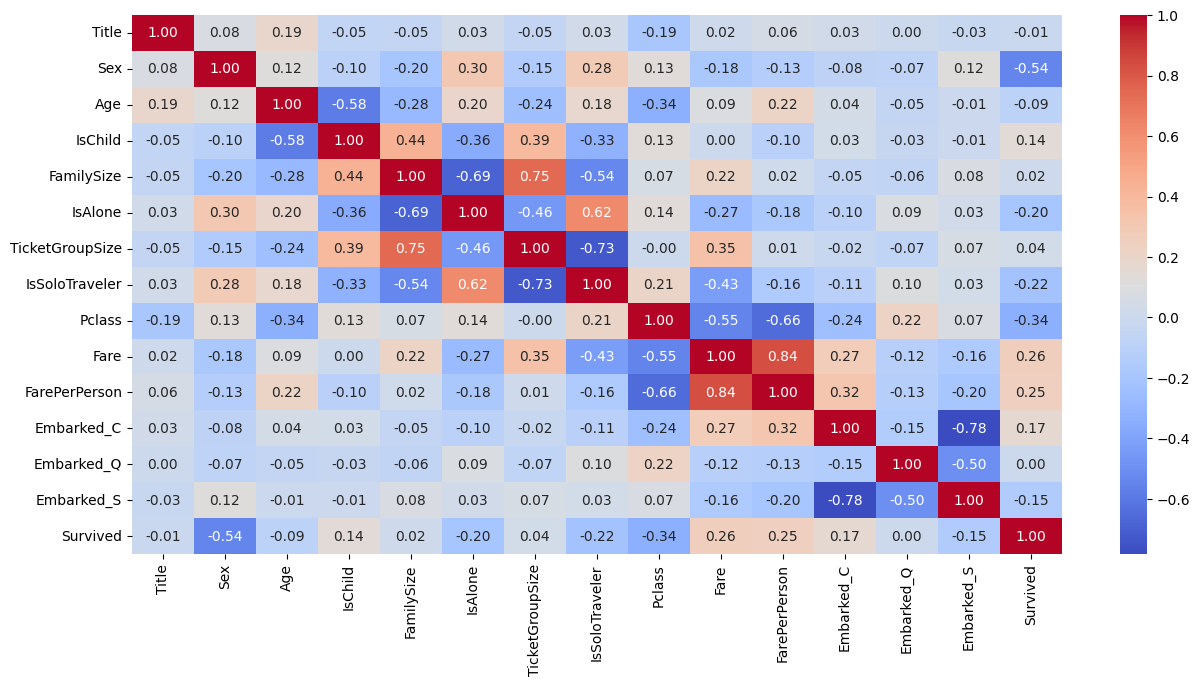

In [926]:
plt.figure(figsize=(15,7))
sns.heatmap(
    data.corr(numeric_only=True),
    annot=True,
    fmt=".2f",
    cmap='coolwarm'
)
plt.show()

### 🧹 I will go back and ...

1. **Drop basic Title features**  
   Remove `Mr`, `Mrs`, `Miss`, and `Master` since their information is largely captured by:
   - `Sex`
   - `Age`
   - `IsChild`

---

2. **Remove raw family features**  
   Drop `SibSp` and `Parch` in favor of the engineered feature:
   - `FamilySize = SibSp + Parch + 1`

In [927]:
data.head()

,Title,Sex,Age,IsChild,FamilySize,IsAlone,TicketGroupSize,IsSoloTraveler,Pclass,Fare,FarePerPerson,Embarked_C,Embarked_Q,Embarked_S,Survived
0,0,1,-0.584567,0,2,0,1,1,3,-0.502445,-0.496976,0,0,1,0
1,0,0,0.621430,0,2,0,1,1,1,0.786845,2.522573,1,0,0,1
2,0,0,-0.283068,0,1,1,1,1,3,-0.488854,-0.465145,0,0,1,1
3,0,0,0.395305,0,2,0,2,0,1,0.420730,0.413134,0,0,1,1
4,0,1,0.395305,0,1,1,1,1,3,-0.486337,-0.459251,0,0,1,0
